In [156]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np


from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Flatten, Dense, Dropout, LSTM, GRU
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Model

#### Functions

In [157]:
def evaluate_model(model, X_test, y_test):
    """
    Avalia um modelo de classificação e exibe métricas detalhadas.

    Args:
      model: Modelo Keras treinado.
      X_test: Dados de teste (features).
      y_test: Rótulos de teste.
    """
    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
    
    print(f"Loss: {loss:.4f}")
    print(f"Acurácia: {accuracy:.4f}")

    y_pred = model.predict(X_test)
    y_pred_classes = np.argmax(y_pred, axis=1)

    # Calculando a matriz de confusão
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_classes).ravel()

    # Calculando as métricas
    tpr = tp / (tp + fn)  # Taxa de verdadeiros positivos (recall)
    tnr = tn / (tn + fp)  # Taxa de verdadeiros negativos
    fnr = fn / (tp + fn)  # Taxa de falsos negativos
    fpr = fp / (tn + fp)  # Taxa de falsos positivos

    precision = tp / (tp + fp)  # Precisão
    recall = tpr  # Recall
    f1 = 2 * (precision * recall) / (precision + recall)  # F1-score
    auc = roc_auc_score(y_test, y_pred_classes)
    
    # Imprimindo as métricas
    print("\nMétricas da Matriz de Confusão:")
    print(f"TN: {tn}")
    print(f"FP: {fp}")
    print(f"FN: {fn}")
    print(f"TP: {tp}")
    print(f"TPR (Recall): {tpr:.4f}")
    print(f"TNR: {tnr:.4f}")
    print(f"FNR: {fnr:.4f}")
    print(f"FPR: {fpr:.4f}")

    print("\nMétricas de Classificação:")
    print(f"Acurácia: {accuracy:.4f}")
    print(f"Precisão: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")
    print(f"AUC: {auc:.4f}")

    # Matriz de Confusão (visualização)
    print("\nMatriz de Confusão:")
    cm = confusion_matrix(y_test, y_pred_classes)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Previsão")
    plt.ylabel("Verdadeiro")
    plt.title("Matriz de Confusão")
    plt.show()

    print("Relatório de Classificação:")
    print(classification_report(y_test, y_pred_classes))

#### Load Data

In [123]:
df_normal = pd.read_parquet('data/result/normal.parquet')
df_imbalance = pd.read_parquet('data/result/imbalance.parquet')
df_overhang = pd.read_parquet('data/result/overhang.parquet')
df_underhang = pd.read_parquet('data/result/underhang.parquet')
df_horizontal_misalignment= pd.read_parquet('data/result/horizontal-misalignment.parquet')
df_vertical_misalignment = pd.read_parquet('data/result/vertical-misalignment.parquet')

#### TC 1 - Todas anomalias

In [124]:
df_anomaly = pd.concat([df_imbalance, df_overhang, df_underhang, df_horizontal_misalignment, df_vertical_misalignment])

In [125]:
#df['target_desc'].value_counts()

In [126]:
samples_per_class = 104

In [127]:
df_other_subsampled = pd.DataFrame()

for label in df_anomaly['target_desc'].unique():
    df_label = df_anomaly[df_anomaly['target_desc'] == label]
    df_label_subsampled = resample(df_label,
                                 replace=False,
                                 n_samples=samples_per_class,
                                 random_state=42)
    df_other_subsampled = pd.concat([df_other_subsampled, df_label_subsampled])

In [128]:
df_balanced = pd.concat([df_normal, df_other_subsampled])
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

In [129]:
df_balanced['target_desc'].value_counts()


target_desc
normal                     245
underhang_cage_fault       104
underhang_outer_race       104
horizontal-misalignment    104
overhang_cage_fault        104
imbalance                  104
underhang_ball_fault       104
overhang_ball_fault        104
vertical-misalignment      104
overhang_outer_race        104
Name: count, dtype: int64

In [130]:
df_normal = df_balanced[df_balanced['target_desc'].isin(['normal'])]
df_train = df_balanced[df_balanced['target_desc'].isin(['vertical-misalignment', 'horizontal-misalignment'])]
df_test = df_balanced[df_balanced['target_desc'].isin(['imbalance'])]

In [131]:
X = df_normal.drop(['target_desc', 'target_parameters', 'target'], axis=1)
y = df_normal['target']
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
X_train['target'] = y_train
X_temp['target'] = y_temp

In [132]:
X_train_temp = df_train.drop(['target_desc', 'target_parameters', 'target'], axis=1)
y_train_temp = df_train['target']
X_train_temp['target'] = y_train_temp
X_train = pd.concat([X_train, X_train_temp])

In [133]:
X_train['target'].value_counts()


target
0    208
1    208
Name: count, dtype: int64

In [134]:
X = X_train.drop(['target'], axis=1)
y = X_train['target']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)

In [135]:
df_test = df_test.sample(n=37, random_state=42).reset_index(drop=True)

In [136]:
X_test_temp = df_test.drop(['target_desc', 'target_parameters', 'target'], axis=1)
y_test_temp = df_test['target']
X_test_temp['target'] = y_test_temp

In [137]:
X_test = pd.concat([X_temp, X_test_temp])
y_test = X_test['target']
X_test = X_test.drop(['target'], axis=1)

In [138]:
X_train.shape, X_val.shape, X_temp.shape

((353, 160), (63, 160), (37, 161))

In [139]:
y_train.value_counts()


target
1    177
0    176
Name: count, dtype: int64

In [140]:
y_val.value_counts()


target
0    32
1    31
Name: count, dtype: int64

In [141]:
y_test.value_counts()


target
0    37
1    37
Name: count, dtype: int64

In [142]:
# Supondo que X_train e y_train já estão definidos (sem o reshape para a CNN)

# Treinar uma Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Obter a importância das features
feature_importances = rf_model.feature_importances_

# Criar um DataFrame para visualizar a importância das features
feature_importance_df = pd.DataFrame({'feature': X_train.columns, 'importance': feature_importances})
feature_importance_df = feature_importance_df.sort_values('importance', ascending=False)

# Exibir as features mais importantes
print(feature_importance_df)

# Selecionar as N features mais importantes
num_features_to_select = 15  # Defina quantas features você quer selecionar
selected_features = feature_importance_df['feature'][:num_features_to_select].tolist()
n_features = len(selected_features)
input_shape = (n_features, 1)
batch_size = 32  # Ajuste conforme necessário
epochs = 100 # Ajuste conforme necessário
num_classes = len(np.unique(y_train))

                            feature  importance
49       uba_radial_shannon_entropy    0.085978
69   uba_tangencial_shannon_entropy    0.072173
152           microphone_fft_freq_2    0.064809
77         uba_tangencial_fft_mag_4    0.054993
52            uba_radial_fft_freq_2    0.039435
..                              ...         ...
8           rot_freq_peak_frequency    0.000000
10              rot_freq_fft_freq_1    0.000000
135        oba_tangencial_fft_mag_3    0.000000
128   oba_tangencial_peak_frequency    0.000000
88         oba_axial_peak_frequency    0.000000

[160 rows x 2 columns]


In [143]:
selected_features = [
    'uba_tangencial_shannon_entropy',
    'oba_radial_kurtosis',
    'uba_radial_shannon_entropy',
    'microphone_fft_freq_2',
    'oba_radial_fft_mag_3',
    'uba_axial_shannon_entropy',
    'oba_radial_fft_mag_2',
    'oba_radial_fft_mag_1',
    'microphone_kurtosis',
    'oba_axial_shannon_entropy',
    'uba_axial_kurtosis',
    'oba_radial_std',
    'uba_radial_fft_freq_1',
    'uba_axial_fft_freq_2',
    'oba_tangencial_fft_freq_1'
]

In [144]:
#categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
#categorical_cols

In [145]:
sc = StandardScaler()

# Aplica o StandardScaler em todas as colunas do DataFrame
X_train_ss = pd.DataFrame(sc.fit_transform(X_train), columns=X_train.columns)
X_test_ss = pd.DataFrame(sc.transform(X_test), columns=X_test.columns)
X_val_ss = pd.DataFrame(sc.transform(X_val), columns=X_val.columns)

In [146]:
X_train_ss = X_train_ss[selected_features]
X_test_ss = X_test_ss[selected_features]
X_val_ss = X_val_ss[selected_features]

In [147]:
X_train_reshaped = X_train_ss.values.reshape(X_train_ss.shape[0], n_features, 1)
X_test_reshaped = X_test_ss.values.reshape(X_test_ss.shape[0], n_features, 1)
X_val_reshaped = X_val_ss.values.reshape(X_val_ss.shape[0], n_features, 1)

In [148]:
def create_cnn_model(input_shape, num_classes):
    input_layer = Input(shape=input_shape)

    x = Conv1D(filters=32, kernel_size=3, activation='relu', padding='same')(input_layer)
    x = MaxPooling1D(pool_size=2)(x)
    x = Dropout(0.2)(x)

    x = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(x)
    x = MaxPooling1D(pool_size=2)(x)
    x = Dropout(0.2)(x)

    x = Flatten()(x)
    x = Dense(100, activation='relu')(x)
    x = Dropout(0.2)(x)

    output_layer = Dense(num_classes, activation='softmax')(x)  # Use softmax para classificação multiclasse

    model = Model(inputs=input_layer, outputs=output_layer)

    model.summary()

    model.compile(optimizer = Adam(),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

    print("Treinando o modelo CNN...")
    model_history = model.fit(X_train_reshaped, y_train,
                    batch_size=batch_size,
                    epochs=epochs,
                    validation_data=(X_val_reshaped, y_val), verbose=0)

    print("\nAvaliando o modelo CNN...")
    evaluate_model(model, X_test_reshaped, y_test)
    
    return model, model_history

In [149]:
def create_rnn_model(input_shape, num_classes):
    """
    Cria um modelo RNN com camadas adicionais para melhorar o desempenho.

    Args:
      input_shape: Forma da entrada (tuple).
      num_classes: Número de classes de saída (int).

    Returns:
      Um modelo Keras compilado.
    """
    input_layer = Input(shape=input_shape)

    # Camadas RNN empilhadas
    x = GRU(64, activation='relu', return_sequences=True)(input_layer)
    x = GRU(32, activation='relu')(x) 

    # Camadas densas adicionais
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.2)(x)

    output_layer = Dense(num_classes, activation='softmax')(x)
    model = Model(inputs=input_layer, outputs=output_layer)
    model.summary()

    model.compile(optimizer = Adam(),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    print("Treinando o modelo RNN...")
    model_history = model.fit(X_train_reshaped, y_train,
                            batch_size=batch_size,
                            epochs=epochs,
                            validation_data=(X_val_reshaped, y_val), verbose=0)

    print("\nAvaliando o modelo RNN...")
    evaluate_model(model, X_test_reshaped, y_test)

    return model, model_history

In [150]:
def create_lstm_model(input_shape, num_classes):
    input_layer = Input(shape=input_shape)
    x = LSTM(50, activation='relu')(input_layer)  # Você pode adicionar mais camadas LSTM
    x = Dropout(0.2)(x)
    x = Dense(100, activation='relu')(x)
    x = Dropout(0.2)(x)
    output_layer = Dense(num_classes, activation='softmax')(x)
    model = Model(inputs=input_layer, outputs=output_layer)

    model.summary()

    model.compile(optimizer = Adam(),
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])


    print("Treinando o modelo LSTM...")
    model_history = model.fit(X_train_reshaped, y_train,
                              batch_size=batch_size,
                              epochs=epochs,
                              validation_data=(X_val_reshaped, y_val), verbose=0)

    print("\nAvaliando o modelo LSTM...")
    evaluate_model(model, X_test_reshaped, y_test)
    
    return model, model_history

W0000 00:00:1736110730.637240  149058 gpu_device.cc:2344] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 15, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 15, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 7, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 7, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 7, 64)          │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 3, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 3, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │        19,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           202 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,838 (100.93 KB)

 Trainable params: 25,838 (100.93 KB)

 Non-trainable params: 0 (0.00 B)

Treinando o modelo CNN...

Avaliando o modelo CNN...
Loss: 2232.9871
Acurácia: 0.8108
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step

Métricas da Matriz de Confusão:
TN: 37
FP: 0
FN: 14
TP: 23
TPR (Recall): 0.6216
TNR: 1.0000
FNR: 0.3784
FPR: 0.0000

Métricas de Classificação:
Acurácia: 0.8108
Precisão: 1.0000
Recall: 0.6216
F1-score: 0.7667
AUC: 0.8108

Matriz de Confusão:


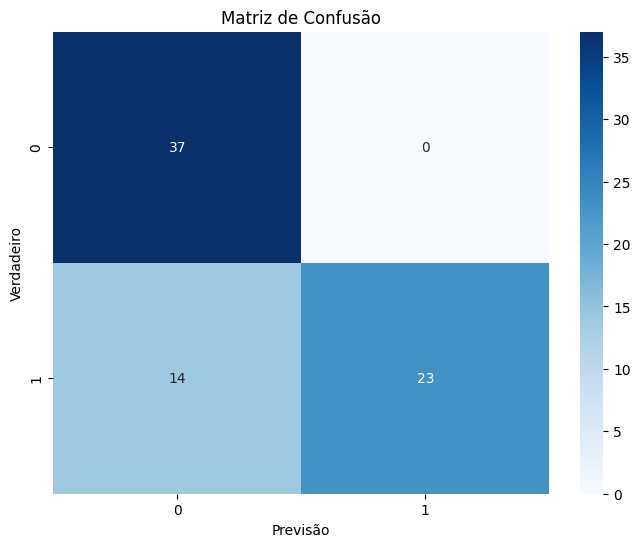

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.73      1.00      0.84        37
           1       1.00      0.62      0.77        37

    accuracy                           0.81        74
   macro avg       0.86      0.81      0.80        74
weighted avg       0.86      0.81      0.80        74



In [151]:
cnn_model, cnn_model_history = create_cnn_model(input_shape, num_classes)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 15, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 15, 64)         │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,882 (136.26 KB)

 Trainable params: 34,882 (136.26 KB)

 Non-trainable params: 0 (0.00 B)

Treinando o modelo RNN...

Avaliando o modelo RNN...
Loss: 4234.7515
Acurácia: 0.8378
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step

Métricas da Matriz de Confusão:
TN: 34
FP: 3
FN: 9
TP: 28
TPR (Recall): 0.7568
TNR: 0.9189
FNR: 0.2432
FPR: 0.0811

Métricas de Classificação:
Acurácia: 0.8378
Precisão: 0.9032
Recall: 0.7568
F1-score: 0.8235
AUC: 0.8378

Matriz de Confusão:


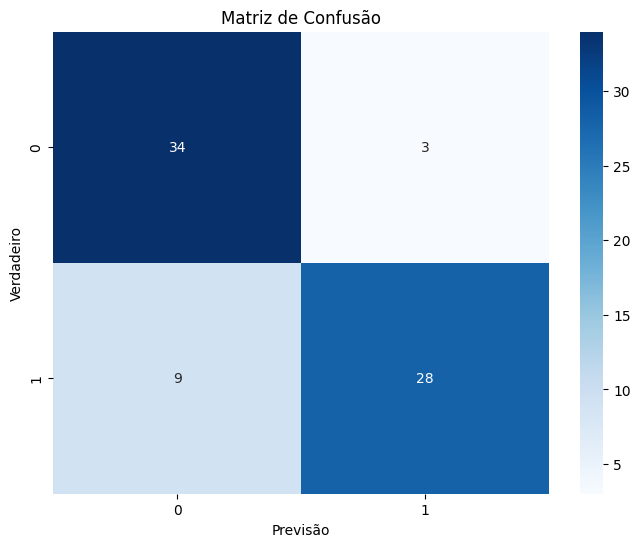

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.79      0.92      0.85        37
           1       0.90      0.76      0.82        37

    accuracy                           0.84        74
   macro avg       0.85      0.84      0.84        74
weighted avg       0.85      0.84      0.84        74



In [152]:
rnn_model, rnn_model_history  = create_rnn_model(input_shape, num_classes)

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 15, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 100)            │         5,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 2)              │           202 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,702 (61.34 KB)

 Trainable params: 15,702 (61.34 KB)

 Non-trainable params: 0 (0.00 B)

Treinando o modelo LSTM...

Avaliando o modelo LSTM...
Loss: 0.3718
Acurácia: 0.8378


[01/05/25 17:59:29] WARNING  5 out of the last 7 calls to <function                     ]8;id=108853;file:///home/pedro/Development/mlprod/venv/lib/python3.9/site-packages/tensorflow/python/eager/polymorphic_function/polymorphic_function.py\polymorphic_function.py]8;;\:]8;id=697477;file:///home/pedro/Development/mlprod/venv/lib/python3.9/site-packages/tensorflow/python/eager/polymorphic_function/polymorphic_function.py#157\157]8;;\
                             TensorFlowTrainer.make_predict_function.<locals>.one_step_                            
                             on_data_distributed at 0x74c1a4727160> triggered                                      
                             tf.function retracing. Tracing is expensive and the                                   
                             excessive number of tracings could be due to (1) creating                             
                             @tf.function repeatedly in a loop, (2) passing tensors                                
                             with different shapes, (3) passing Python objects instead                             
                             of tensors. For (1), please define your @tf.function                                  
                             outside of the loop. For (2), @tf.function has                                        
                             reduce_retracing=True option that can avoid unnecessary                               
                             retracing. For (3), please refer to                                                   
                             https://www.tensorflow.org/guide/function#controlling_retr                            
                             acing and                                                                             
                             https://www.tensorflow.org/api_docs/python/tf/function for                            
                             more details.                                                                         

1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step

                    WARNING  6 out of the last 9 calls to <function                     ]8;id=438028;file:///home/pedro/Development/mlprod/venv/lib/python3.9/site-packages/tensorflow/python/eager/polymorphic_function/polymorphic_function.py\polymorphic_function.py]8;;\:]8;id=446263;file:///home/pedro/Development/mlprod/venv/lib/python3.9/site-packages/tensorflow/python/eager/polymorphic_function/polymorphic_function.py#157\157]8;;\
                             TensorFlowTrainer.make_predict_function.<locals>.one_step_                            
                             on_data_distributed at 0x74c1a4727160> triggered                                      
                             tf.function retracing. Tracing is expensive and the                                   
                             excessive number of tracings could be due to (1) creating                             
                             @tf.function repeatedly in a loop, (2) passing tensors                                
                             with different shapes, (3) passing Python objects instead                             
                             of tensors. For (1), please define your @tf.function                                  
                             outside of the loop. For (2), @tf.function has                                        
                             reduce_retracing=True option that can avoid unnecessary                               
                             retracing. For (3), please refer to                                                   
                             https://www.tensorflow.org/guide/function#controlling_retr                            
                             acing and                                                                             
                             https://www.tensorflow.org/api_docs/python/tf/function for                            
                             more details.                                                                         

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step

Métricas da Matriz de Confusão:
TN: 32
FP: 5
FN: 7
TP: 30
TPR (Recall): 0.8108
TNR: 0.8649
FNR: 0.1892
FPR: 0.1351

Métricas de Classificação:
Acurácia: 0.8378
Precisão: 0.8571
Recall: 0.8108
F1-score: 0.8333
AUC: 0.8378

Matriz de Confusão:


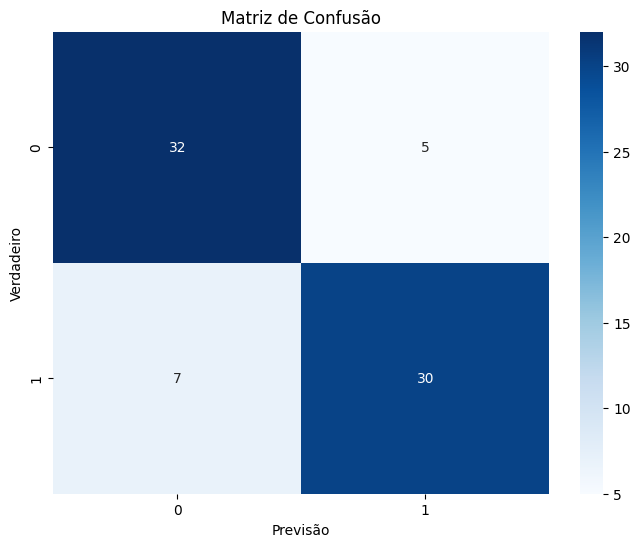

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.82      0.86      0.84        37
           1       0.86      0.81      0.83        37

    accuracy                           0.84        74
   macro avg       0.84      0.84      0.84        74
weighted avg       0.84      0.84      0.84        74



In [153]:
lstm_model, lstm_model_history = create_lstm_model(input_shape, num_classes)

In [154]:
X_train['target'] = y_train
X_val['target'] = y_val
X_test['target'] = y_test

In [155]:
X_train.to_parquet('data/result/exp_4/train.parquet')
X_val.to_parquet('data/result/exp_4/val.parquet')
X_test.to_parquet('data/result/exp_4/test.parquet')